# Cross Spectrum

In [51]:
# import useful libraries
import numpy as np
import matplotlib.pyplot as plt
import torch 

import sys
from pathlib import Path

# set parent directory to sys.path for imports
NOTEBOOK_DIR = Path.cwd().resolve()
PARENT_DIR = NOTEBOOK_DIR.parents[2]
if str(PARENT_DIR) not in sys.path:
    sys.path.insert(0, str(PARENT_DIR))
    print(f"Parent directory added to sys.path: ...\\{PARENT_DIR.name}")
else:
    print(f"Parent directory already in sys.path: ...\\{PARENT_DIR.name}")


# set dataset directory path
DATA_TEST_PATH = PARENT_DIR / "data" / "test"
print("Dataset directory used:", f"...\\{PARENT_DIR.name}\\{DATA_TEST_PATH.relative_to(PARENT_DIR)}")

from STL_main.STL_2D_Kernel_Torch import STL_2D_Kernel_Torch

Parent directory already in sys.path: ...\STL-Dev
Dataset directory used: ...\STL-Dev\data\test


In [52]:
# command to auto-reload modules when they are edited (easier for testing and debugging)
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


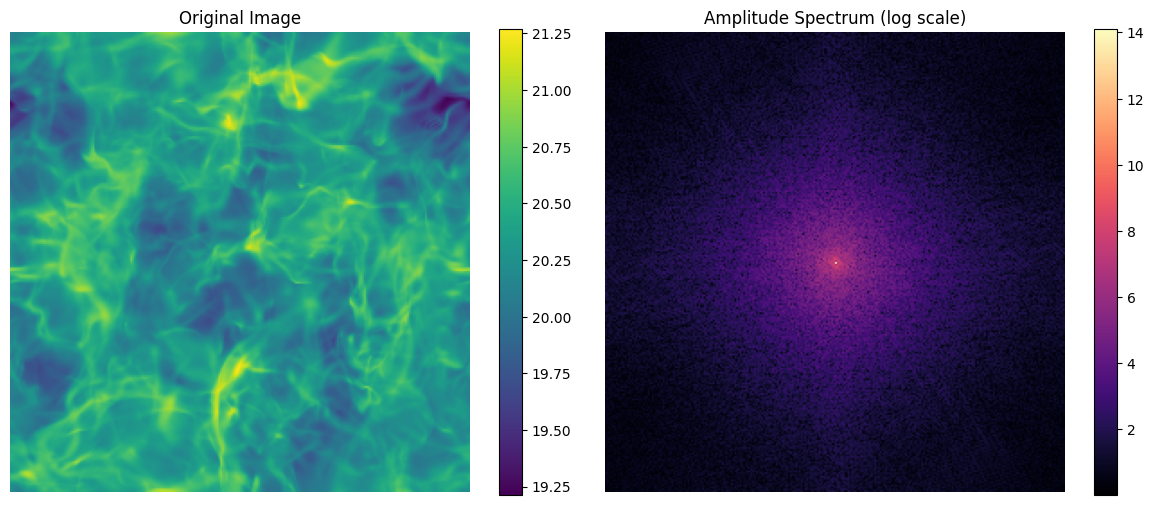

In [53]:
# Load periodic data
im = np.load(str(DATA_TEST_PATH) + "/" + "Turb_6.npy")[0]
im = torch.from_numpy(im).float()

# Compute FFT amplitude spectrum
im_fft = torch.fft.fftshift(torch.fft.fft2(im))
im_fft_amp = torch.abs(im_fft)

# Plot original data and amplitude spectrum
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.title("Original Image")
plt.imshow(im.numpy(), cmap="viridis")
plt.axis("off")
plt.colorbar()

plt.subplot(1, 2, 2)
plt.title("Amplitude Spectrum (log scale)")
plt.imshow(torch.log1p(im_fft_amp).numpy(), cmap="magma")
plt.axis("off")
plt.colorbar()

plt.tight_layout()
plt.show()

In [54]:
# Instantiate FFT dataclasse
data = STL_2D_Kernel_Torch(array=im, pbc=True)
data_no_pbc = STL_2D_Kernel_Torch(array=im, pbc=False)

# Get PS operator   
cs_op = data.get_CS_op(binning_type="legacy")

In [55]:
print("Minimal frequency:", round(cs_op.k_min, 3))
print("Maximal frequency (pre-Nyquist):", round(cs_op.k_max, 3))

Minimal frequency: 0.011
Maximal frequency (pre-Nyquist): 0.354


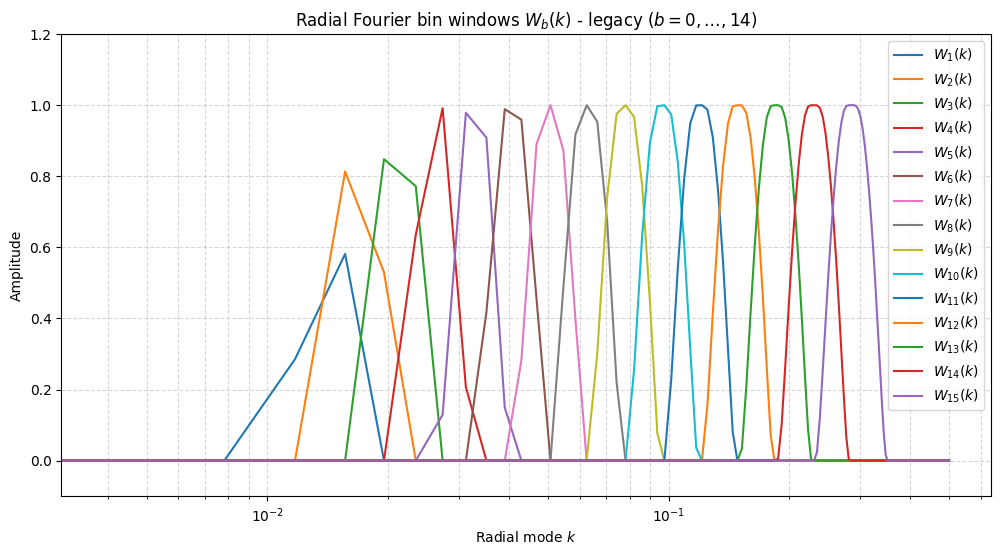

In [56]:
# 1D radial profile of the bin windows + LP check
plt.figure(figsize=(12, 6))
for i in range(cs_op.n_bins):
    plt.plot(cs_op.radial_k, cs_op.bin_windows[i], label=fr"$W_{{{i+1}}}(k)$")

plt.ylim(-0.1, 1.2)
plt.title(
    f"Radial Fourier bin windows $W_b(k)$ - {cs_op.binning_type} "
    f"($b={0},\ldots,{cs_op.n_bins-1}$)"
)
plt.xscale("log")
plt.xlabel("Radial mode $k$")
plt.ylabel("Amplitude")
plt.legend()
plt.grid(True, which='both', linestyle='--', alpha=0.5)
plt.show()

In the figure with a linear frequency scale, we observe a degradation in the quality of the wavelets at low frequencies. This can be explained by the image resolution.

Let us check the spectral coverage condition and the bin windows over the range of modes probed by the scattering wavelets.

Note: by construction, the coverage vanishes at the boundary of the last wavelet, at $k_{\max}$.


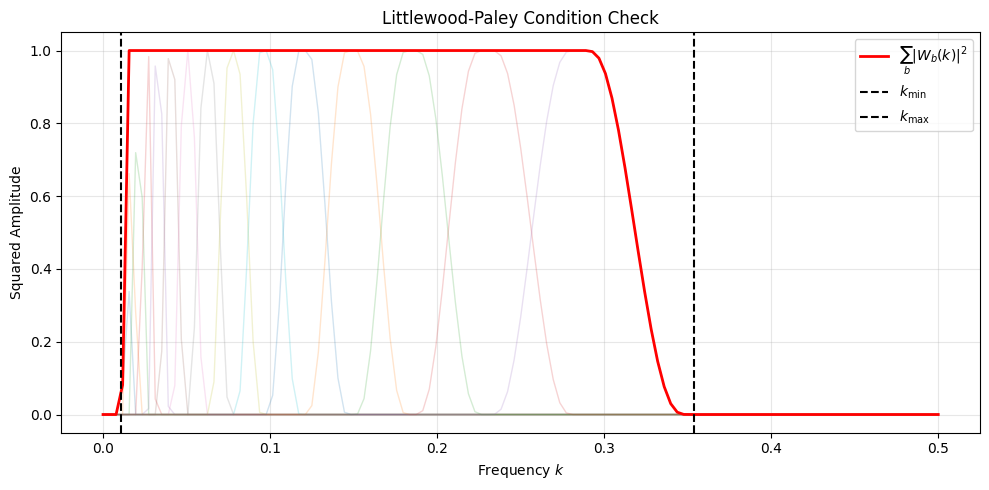

In [57]:
lp_sum = torch.sum(torch.abs(cs_op.bin_windows) ** 2, dim=0)

fig, ax = plt.subplots(figsize=(10, 5))

for i in range(cs_op.n_bins):
    ax.plot(
        cs_op.radial_k,
        cs_op.bin_windows[i] ** 2,
        alpha=0.2,
        lw=1,
    )

ax.plot(
    cs_op.radial_k,
    lp_sum,
    "r",
    lw=2,
    label=r"$\sum_b |W_b(k)|^2$",
)

ax.axvline(
    cs_op.k_min,
    linestyle="--",
    color="k",
    lw=1.5,
    label=r"$k_{\min}$",
)

ax.axvline(
    cs_op.k_max,
    linestyle="--",
    color="k",
    lw=1.5,
    label=r"$k_{\max}$",
)


ax.set_xlabel("Frequency $k$")
ax.set_ylabel("Squared Amplitude")
ax.set_title("Littlewood-Paley Condition Check")
ax.legend(loc="upper right")
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [58]:
print(cs_op.crop_borders)

tensor([47, 40, 45, 39, 34, 26, 21, 18, 14, 12,  9,  8,  6,  5,  5])


Let’s compare the power spectrum of a PBC image without NaNs using the `fft`, `pbc_mask`, `nan_mask`, and `pbc_nan_mask` methods to check for good agreement between the spectra.

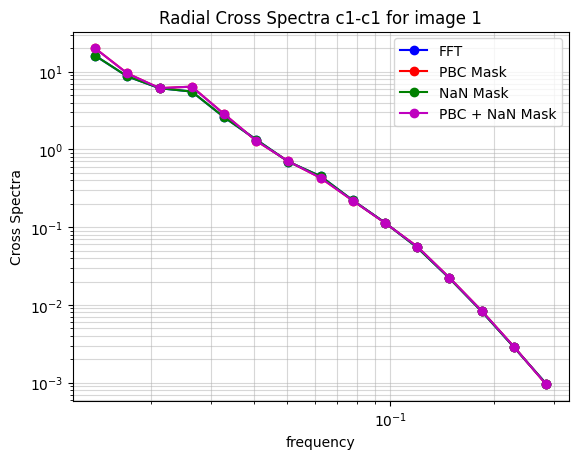

In [59]:
# Compute power spectrum for different spectrum methods
cross_spectrum= cs_op.apply(data, spectrum_method="fft")
cross_spectrum_pbc_mask = cs_op.apply(data, spectrum_method="pbc_mask")
cross_spectrum_nan_mask = cs_op.apply(data, spectrum_method="nan_mask")
cross_spectrum_pbc_nan_mask = cs_op.apply(data, spectrum_method="pbc_nan_mask")

# Compare power spectra (should be aligned for the same periodic and without NaNs data, even if specified some masking method)
cs_op.plot_cross_spectrum(cross_spectrum.real, b=0, c1=0, c2=0, label="FFT", color="b")
cs_op.plot_cross_spectrum(cross_spectrum_pbc_mask.real, b=0, c1=0, c2=0, label="PBC Mask", color="r")
cs_op.plot_cross_spectrum(cross_spectrum_nan_mask.real, b=0, c1=0, c2=0, label="NaN Mask", color="g")
cs_op.plot_cross_spectrum(cross_spectrum_pbc_nan_mask.real, b=0, c1=0, c2=0, label="PBC + NaN Mask", color="m")

Great, it fits pretty well!

The slightly poorer agreement at low frequencies can be explained by the larger number of cropped pixels compared to the smaller scales.

Let’s now compare the power spectra for the following four cases with the recommended estimator:

* PBC data without NaNs,
* real non-PBC data without NaNs,
* PBC data with NaNs,
* real non-PBC data with NaNs.


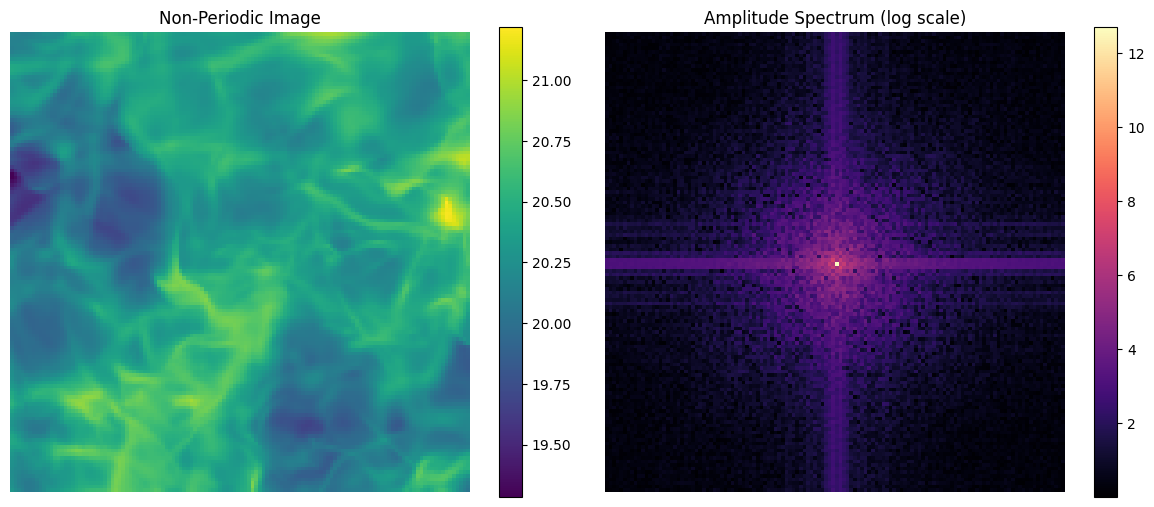

In [60]:
# Extract non periodic portion (128x128) from the original data
im_no_pbc = im[0:128, 0:128]

# Compute FFT amplitude spectrum of non periodic data
im_no_pbc_fft = torch.fft.fftshift(torch.fft.fft2(im_no_pbc))
im_no_pbc_fft_amp = torch.abs(im_no_pbc_fft)

# Plot non periodic data and its amplitude spectrum
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.title("Non-Periodic Image")
plt.imshow(im_no_pbc.numpy(), cmap="viridis")
plt.axis("off")
plt.colorbar()

plt.subplot(1, 2, 2)
plt.title("Amplitude Spectrum (log scale)")
plt.imshow(torch.log1p(im_no_pbc_fft_amp).numpy(), cmap="magma")
plt.axis("off")
plt.colorbar()

plt.tight_layout()
plt.show()

The spectral leakage cross is strong here because we crop the original image at the level of a structure, which makes the extracted image highly non-periodic.

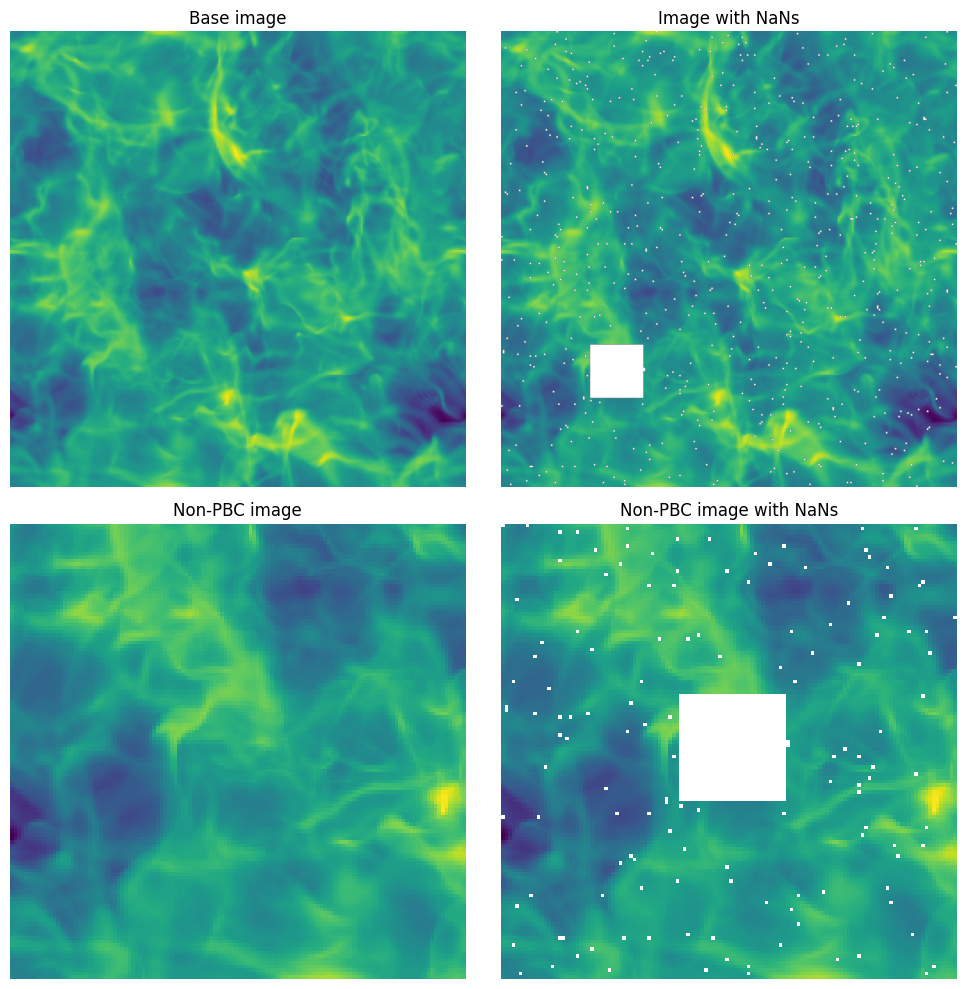

In [61]:
# Add NaNs to the PBC image for testing the nan_mask method
im_nan = im.clone()

np.random.seed(32)

im_nan[
    (np.random.rand(600) * im_nan.shape[0]).astype(int),
    (np.random.rand(600) * im_nan.shape[1]).astype(int),
] = np.nan

im_nan[50:80, 50:80] = np.nan

# Crop the PBC NaN image to get a non-PBC NaN image
# for testing the pbc_nan_mask method
im_nan_no_pbc = im_nan[0:128, 0:128]

# Plot the four images
fig, axes = plt.subplots(2, 2, figsize=(10, 10))

images = [
    im,
    im_nan,
    im_no_pbc,
    im_nan_no_pbc,
]

titles = [
    "Base image",
    "Image with NaNs",
    "Non-PBC image",
    "Non-PBC image with NaNs",
]

for ax, image, title in zip(axes.flat, images, titles):
    im_plot = ax.imshow(image, origin="lower")
    ax.set_title(title)
    ax.axis("off")

plt.tight_layout()
plt.show()

In [66]:
# Instantiate Kernel dataclasses for each type of image (periodic and non-periodic, with and without NaNs)
data = STL_2D_Kernel_Torch(array=im, pbc=True)
data_no_pbc = STL_2D_Kernel_Torch(array=im_no_pbc, pbc=False)
data_nan = STL_2D_Kernel_Torch(array=im_nan, pbc=True)
data_nan_no_pbc = STL_2D_Kernel_Torch(array=im_nan_no_pbc, pbc=False)

# Get PS operator (different because build on different data shapes)
cs_op = data.get_CS_op()
cs_op_no_pbc = data_no_pbc.get_CS_op()

# Compute power spectrum
cross_spectrum = cs_op.apply(data, spectrum_method="fft").real[0, 0, 0, :]
cross_spectrum_no_pbc = cs_op_no_pbc.apply(data_no_pbc, spectrum_method="pbc_mask").real[0, 0, 0, :]
cross_spectrum_nan = cs_op.apply(data_nan, spectrum_method="nan_mask").real[0, 0, 0, :]
cross_spectrum_nan_no_pbc = cs_op_no_pbc.apply(data_nan_no_pbc, spectrum_method="pbc_nan_mask").real[0, 0, 0, :]

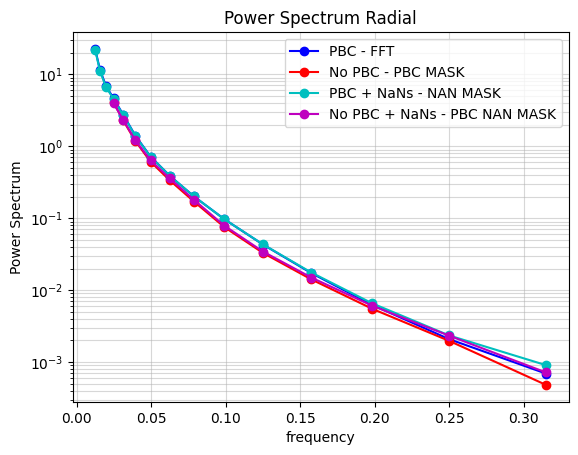

In [67]:
# Plot power spectra for all types of images/methods
plt.plot(cs_op.bin_centers, cross_spectrum, "-", marker="o", label="PBC - FFT", color="b")
plt.plot(cs_op_no_pbc.bin_centers, cross_spectrum_no_pbc, "-", marker="o", label="No PBC - PBC MASK", color="r")
plt.plot(cs_op.bin_centers, cross_spectrum_nan, "-", marker="o", label="PBC + NaNs - NAN MASK", color="c")
plt.plot(cs_op_no_pbc.bin_centers, cross_spectrum_nan_no_pbc, "-", marker="o", label="No PBC + NaNs - PBC NAN MASK", color="m")

plt.yscale("log")
plt.xlabel("frequency")
plt.ylabel("Power Spectrum")
plt.title("Power Spectrum Radial")
plt.grid(True, which="both", ls="-", alpha=0.5)
plt.legend()

Let's compare the cross-power spectra of a PBC image using the `fft`, `nan_mask`, `pbc_mask`, and `pbc_nan_mask` methods.
 

In [47]:
im = np.load(str(DATA_TEST_PATH) + "/" + "Turb_6.npy")[:3] # Take 3 channels for cross spectrum

# Instantiate FFT dataclasse
data = STL_2D_Kernel_Torch(array=im, pbc=True)

# Get PS operator
cs_op = data.get_CS_op()

# Compute power spectrum for both periodic and non-periodic data
compute_cross_spectrum_matrix = torch.tensor([[True, True, True],[False, True, True],[False, False, True]])
cross_spectrum = cs_op.apply(data, compute_cross_spectrum_matrix=compute_cross_spectrum_matrix, spectrum_method="fft")
cross_spectrum_pbc_mask = cs_op.apply(data, compute_cross_spectrum_matrix=compute_cross_spectrum_matrix, spectrum_method="pbc_mask")
cross_spectrum_nan_mask = cs_op.apply(data, compute_cross_spectrum_matrix=compute_cross_spectrum_matrix, spectrum_method="nan_mask")
cross_spectrum_pbc_nan_mask = cs_op.apply(data, compute_cross_spectrum_matrix=compute_cross_spectrum_matrix, spectrum_method="pbc_nan_mask")


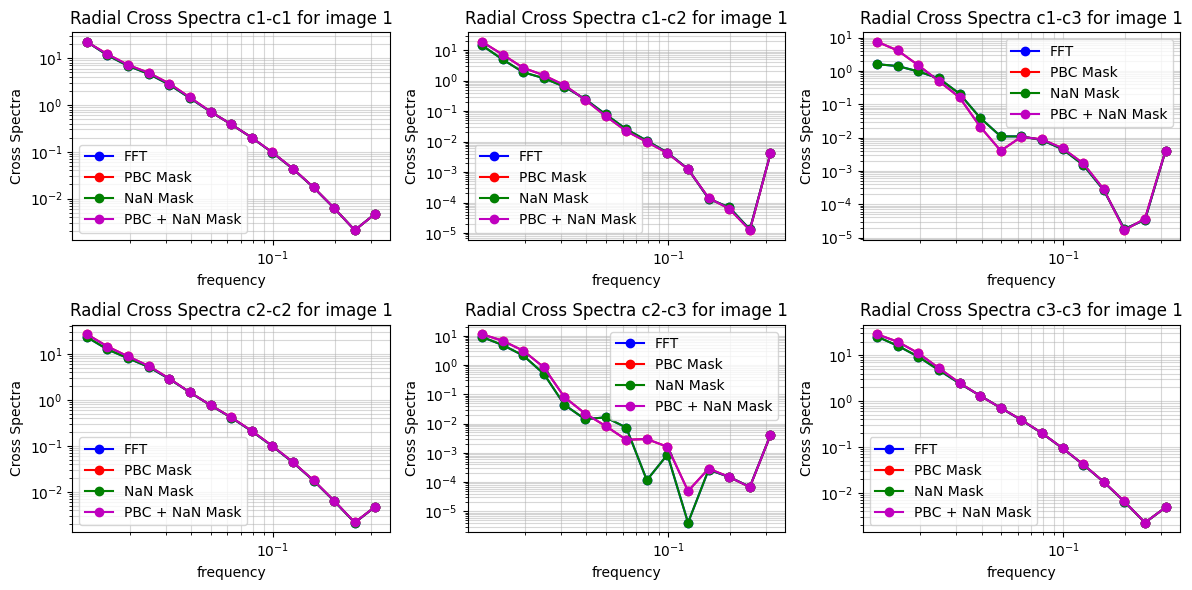

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(12, 6))
axes = axes.ravel()

pairs = [(0,0), (0,1), (0,2), (1,1), (1,2), (2,2)]

for i, (c1, c2) in enumerate(pairs):
    plt.sca(axes[i])

    cs_op.plot_cross_spectrum(
        cross_spectrum.abs(), b=0, c1=c1, c2=c2,
        label="FFT", color="b"
    )

    cs_op.plot_cross_spectrum(
        cross_spectrum_pbc_mask.abs(), b=0, c1=c1, c2=c2,
        label="PBC Mask", color="r"
    )

    cs_op.plot_cross_spectrum(
        cross_spectrum_nan_mask.abs(), b=0, c1=c1, c2=c2,
        label="NaN Mask", color="g"
    )
    
    cs_op.plot_cross_spectrum(
        cross_spectrum_pbc_nan_mask.abs(), b=0, c1=c1, c2=c2,
        label="PBC + NaN Mask", color="m"
    )
    
    plt.legend()

plt.tight_layout()
plt.show()

For a given channel pair $(c_1,c_2)$ and bin $b$, points where the `fft` and `pbc_mask`/`pbc_nan_mask` cross-spectra do not overlap correspond to realizations for which the `fft` estimate is small compared with the standard deviation of the `pbc_mask` estimator, which is partly induced by the cropping process.

The ratio between the `fft` estimate and the standard deviation of the `pbc_mask` estimator therefore provides an indication of how plausible such a non-overlap is.